**what_were_covering**

1: "data (prepare and load)",

2: "build model",

3: "fitting the model to data (training)",

4: "making predictions and evaluating a model (inference)",

5: "saving and loading a model",

6: "putting it all together"

In [40]:
import torch
from torch import nn #nn contains all of pytorch's building blocks for neural networks
import matplotlib.pyplot as plt

#check pytorch version
torch.__version__

'2.7.1+cu118'

1. Data (prepare and load)

Machine learning is a game of two parts:

* Turn your data, whatever it is, into numbers (a representation).
* Pick or build a model to learn the representation as best as possible.

We'll use linear regression to create the data with known parameters (things that can be learned by a model) and then we'll use PyTorch to see if we can build model to estimate these parameters using gradient descent.



In [41]:
#create known parameters
weight = 0.7
bias = 0.3

#create 
start = 0
end = 1
step = 0.02
x = torch.arange(start, end, step,).unsqueeze(dim=1)
y = weight * X + bias

x[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [42]:
len(x), len(y)

(50, 50)

Spliting data into training and test sets

In [43]:
train_split = int(0.8 * len(X))
x_train, y_train = X[:train_split], y[:train_split]
x_test, y_test = X[train_split:], y[train_split:]

len(x_train), len(y_train), len(x_test), len(y_test)

(40, 40, 10, 10)

create a function to visualize it.

In [44]:
def plot_prediction(train_data=x_train,
                    train_labels=y_train,
                    test_data=x_test,
                    test_labels=y_test,
                    predictions=None):
     """
  Plots training data, test data and compares predictions.
     """
     plt.figure(figsize=(10,7))

     #plot training data
     plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")

     #plot test data
     plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

     if predictions is not None:
    # Plot the predictions 
        plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

        #show the legend
        plt.legend(prop={"size": 14})

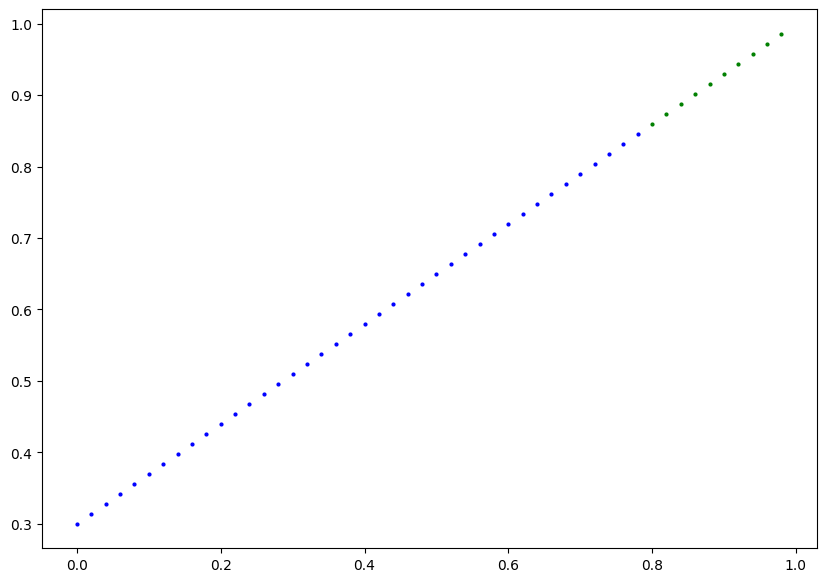

In [45]:
plot_prediction()

**Build Model**

Let's replicate a standard linear regression model using pure PyTorch.

In [46]:
# Create a Linear Regression model class
class LinearRegressionModel(nn.Module): 
    def __init__(self):
        super().__init__() 

        #initiate model parameters to be used for various computations
        self.weights = nn.Parameter(torch.randn(1, 
                                                dtype=torch.float), 
                                   requires_grad=True) 

        self.bias = nn.Parameter(torch.randn(1, 
                                            dtype=torch.float),
                                requires_grad=True)
        
    # Forward() defines the computation in the model
    def forward(self, x: torch.Tensor) -> torch.Tensor: 
        return self.weights * x + self.bias

**PyTorch model building essentials**

PyTorch has four (give or take) essential modules you can use to create almost any kind of neural network you can imagine.

They are **torch.nn**, **torch.optim**, **torch.utils.data.Dataset** and **torch.utils.data.DataLoader**


-----------------------

**torch.nn**  
* A module that contains pre-built layers, loss functions, and neural network tools
* Used to build neural networks easily

**torch.nn.Parameter**
* A special tensor that is automatically treated as a learnable parameter
* When added to a model, PyTorch will update it during training

**torch.nn.Module**
* The base class for all neural networks
* Every model you create must inherit from this

**torch.optim**
* Contains optimizers used to update model weights
* Helps the model learn from errors


**def forward()**
* Defines how data flows through the network
* This is the actual computation step


-----------------------------------------------

create a model instance with the class we've made and check its parameters using .parameters().

In [47]:
# Set manual seed since nn.Parameter are randomly initialized
torch.manual_seed(42)

# Create an instance of the model (this is a subclass of nn.Module that contains nn.Parameter(s))
model_0 = LinearRegressionModel()

# Check the nn.Parameter(s) within the nn.Module subclass we created
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [48]:
# List named parameters 
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

**Making predictions using torch.inference_mode()**

In [49]:
#make predictions with model 
with torch.inference_mode():
    y_preds = model_0(x_test)

In [50]:
#check the predictions
print(f"number of testing samples: {len(x_test)}")
print(f"number of predictions made: {len(y_preds)}")
print(f"predicted values:\n{y_preds}")

number of testing samples: 10
number of predictions made: 10
predicted values:
tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])


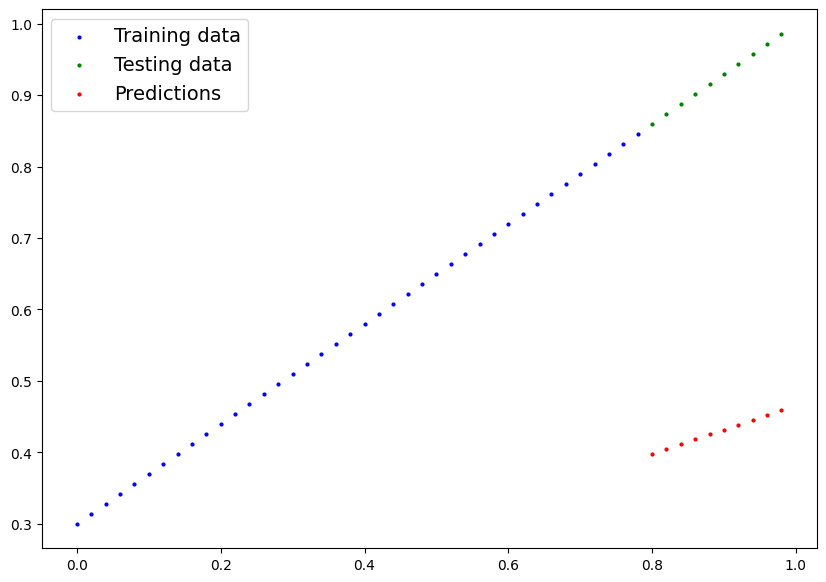

In [51]:
plot_prediction(predictions=y_preds)

In [52]:
y_test - y_preds

tensor([[0.4618],
        [0.4691],
        [0.4764],
        [0.4836],
        [0.4909],
        [0.4982],
        [0.5054],
        [0.5127],
        [0.5200],
        [0.5272]])

our model is just using random parameter values to make predictions.so this is bad 

**Train model**

our model is making predictions using random parameters to make calculations. To fix that, we can update its internal parameters


**Creating a loss function and optimizer in PyTorch**

* Loss function - Measures how wrong your model's predictions 
* Optimizer - Tells your model how to update its internal parameters to best lower the loss.

In [53]:
#create a loss function
loss_fn = nn.L1Loss() #MAE loss is same as L1loss

#create the optimizer
optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.01)

create a training loop and testing loop.

For the training loop, we'll build the following steps:
1. Forward pass
2. Calculate the loss
3. Zero gradients
4. Perform backpropagation on the loss
5. Update the optimizer (gradient descent)

for the testing loop
1. Forward pass
2. Calculate the loss
3. 	Calulate evaluation metrics (optional)

In [54]:
torch.manual_seed(42)

epochs=100

#create empty loss lists to track values
train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
    #training
    
    #put model in training mode
    model_0.train()

    #1.forward pass
    y_pred = model_0(x_train)

    #2.calculate the loss
    loss = loss_fn(y_pred, y_train)

    #3.zero gradient
    optimizer.zero_grad()

    #4.loss backward
    loss.backward()

    #5.prograss the optimizer
    optimizer.step()

    #testing

    #put the model in evalaution mode
    model_0.eval()

    with torch.inference_mode():
        #1.forward pass on test data
        test_pred = model_0(x_test)

        #2.calculate loss on test data 
        test_loss = loss_fn(test_pred, y_test.type(torch.float)) 

        if epoch % 10 == 0:
            epoch_count.append(epoch)
            train_loss_values.append(loss.detach().numpy())
            test_loss_values.append(test_loss.detach().numpy())
            print(f"epoch: {epoch} | MAE Train Loss: {loss} |MAE Test loss: {test_loss} ")



epoch: 0 | MAE Train Loss: 0.31288138031959534 |MAE Test loss: 0.48106518387794495 
epoch: 10 | MAE Train Loss: 0.1976713240146637 |MAE Test loss: 0.3463551998138428 
epoch: 20 | MAE Train Loss: 0.08908725529909134 |MAE Test loss: 0.21729660034179688 
epoch: 30 | MAE Train Loss: 0.053148526698350906 |MAE Test loss: 0.14464017748832703 
epoch: 40 | MAE Train Loss: 0.04543796554207802 |MAE Test loss: 0.11360953003168106 
epoch: 50 | MAE Train Loss: 0.04167863354086876 |MAE Test loss: 0.09919948130846024 
epoch: 60 | MAE Train Loss: 0.03818932920694351 |MAE Test loss: 0.08886633068323135 
epoch: 70 | MAE Train Loss: 0.03476089984178543 |MAE Test loss: 0.0805937647819519 
epoch: 80 | MAE Train Loss: 0.03132382780313492 |MAE Test loss: 0.07232122868299484 
epoch: 90 | MAE Train Loss: 0.02788739837706089 |MAE Test loss: 0.06473556160926819 


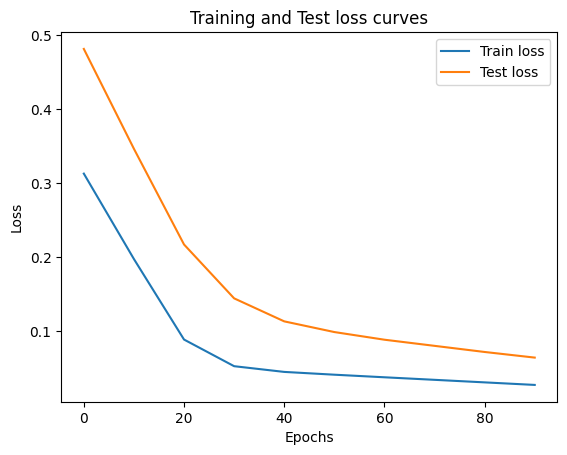

In [55]:
#plot the loss curves
plt.plot(epoch_count, train_loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and Test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

The loss curves show the loss going down over time. Remember, loss is the measure of how wrong your model is, so the lower the better.

In [57]:
#find our model's learned parameters
print("The model learned the following values for weights and bias:")
print(model_0.state_dict())
print(f"original values for weights and bias are: weights = {weight}, bias = {bias}")

The model learned the following values for weights and bias:
OrderedDict([('weights', tensor([0.5784])), ('bias', tensor([0.3513]))])
original values for weights and bias are: weights = 0.7, bias = 0.3


Our model got very close to calculating the exact original values for weight and bias (and it would probably get even closer if we trained it for longer).

**Making predictions with a trained PyTorch model (inference)**

There are three things to remember when making predictions (also called performing inference) with a PyTorch model:

1. Set the model in evaluation mode (**model.eval()**).
2. Make the predictions using the inference mode context manager (**with torch.inference_mode(): ...**).
3. All predictions should be made with objects on the same device (e.g. data and model on GPU only or data and model on CPU only).

In [58]:
#set the model in evaluation mode
model_0.eval()

#setup the inference mode context manager
with torch.inference_mode():
  #Make sure the calculations are done with the model and data on the same device
  # in our case, we haven't setup device-agnostic code yet so our data and model are
  # on the CPU by default.
  y_preds = model_0(x_test)
y_preds


tensor([[0.8141],
        [0.8256],
        [0.8372],
        [0.8488],
        [0.8603],
        [0.8719],
        [0.8835],
        [0.8950],
        [0.9066],
        [0.9182]])

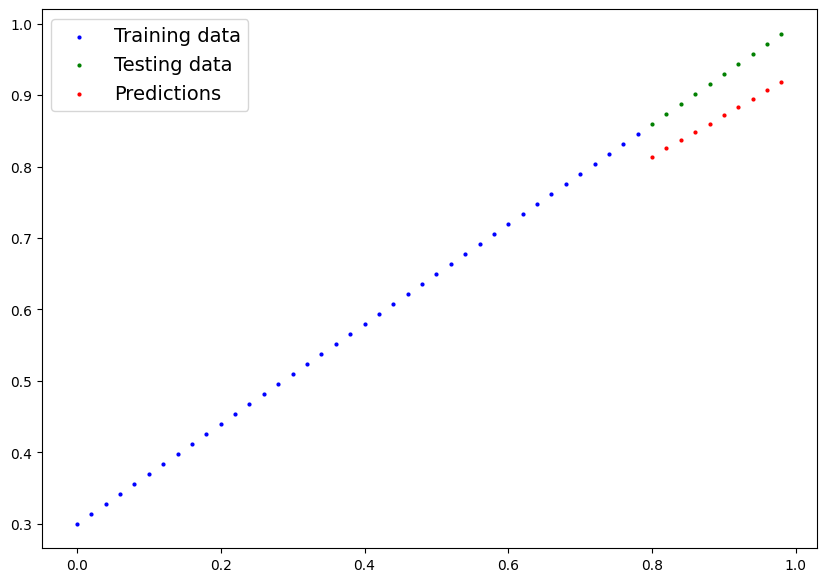

In [60]:
plot_prediction(predictions=y_preds)

**Saving and loading a PyTorch model**




Saving a PyTorch model's state_dict()

1. We'll create a directory for saving models to called models using Python's pathlib module.
2. We'll create a file path to save the model to.
3. We'll call torch.save(obj, f) where obj is the target model's state_dict() and f is the filename of where to save the model.


In [62]:
from pathlib import Path

#create models directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

#create model save patj
MODEL_NAME = "01_pytorch_workflow_model_0.pth"
MODEL_SAVE_PATH = MODEL_PATH/ MODEL_NAME

#save the model state dict
print(f"saving model to {MODEL_SAVE_PATH}")
torch.save(obj=model_0.state_dict(), f=MODEL_SAVE_PATH)

saving model to models\01_pytorch_workflow_model_0.pth


Loading a saved PyTorch model's state_dict()

we can now load it in using torch.nn.Module.load_state_dict(torch.load(f)) where f is the filepath of our saved model state_dict().

In [64]:
# Instantiate a new instance of our model
loaded_model_0 = LinearRegressionModel()

# Load the state_dict of our saved model
loaded_model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

<All keys matched successfully>

Now to test our loaded model,

In [65]:
#loaded model to eval mode
loaded_model_0.eval()

#Use the inference mode context manager to make predictions
with torch.inference_mode():
    loaded_model_preds = loaded_model_0(x_test)


In [66]:
y_preds == loaded_model_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

he loaded model predictions are the same as the previous model predictions